In [1]:
import sqlite3
import pandas as pd
from pathlib import Path
import plotly.express as px

db_path = Path.cwd().parent / "tempo_dev.db"
conn = sqlite3.connect(db_path)

samples = pd.read_sql("SELECT * FROM health_samples ORDER BY start_date DESC LIMIT 5", conn)
samples

,uuid,type,quantity,start_date,end_date,inserted_at,updated_at
0,182E1D44-C1AE-46F2-AE56-273B8957123B,HKQuantityTypeIdentifierSixMinuteWalkTestDistance,500.000000,2026-01-18T16:04:22Z,2026-01-18T16:04:22Z,2026-01-18T16:16:14,2026-01-18T16:16:14
1,67E6F061-8873-4A4B-8CDA-7285D1D8D12F,HKQuantityTypeIdentifierFlightsClimbed,1.000000,2026-01-18T14:56:05Z,2026-01-18T14:56:10Z,2026-01-18T16:16:13,2026-01-18T16:16:13
2,8C83001C-F69F-429F-BD26-F4D57AF54693,HKQuantityTypeIdentifierStairAscentSpeed,0.303842,2026-01-18T14:55:44Z,2026-01-18T14:55:51Z,2026-01-18T16:16:15,2026-01-18T16:16:15
3,F36C7F1B-B2B6-49C6-967C-E06AAAEDA287,HKQuantityTypeIdentifierStepCount,48.000000,2026-01-18T14:55:13Z,2026-01-18T14:56:02Z,2026-01-18T16:16:16,2026-01-18T16:16:16
4,6835D7C1-404D-4900-87DF-9AABF9CC7B64,HKQuantityTypeIdentifierDistanceWalkingRunning,0.018871,2026-01-18T14:55:13Z,2026-01-18T14:56:02Z,2026-01-18T16:16:13,2026-01-18T16:16:13


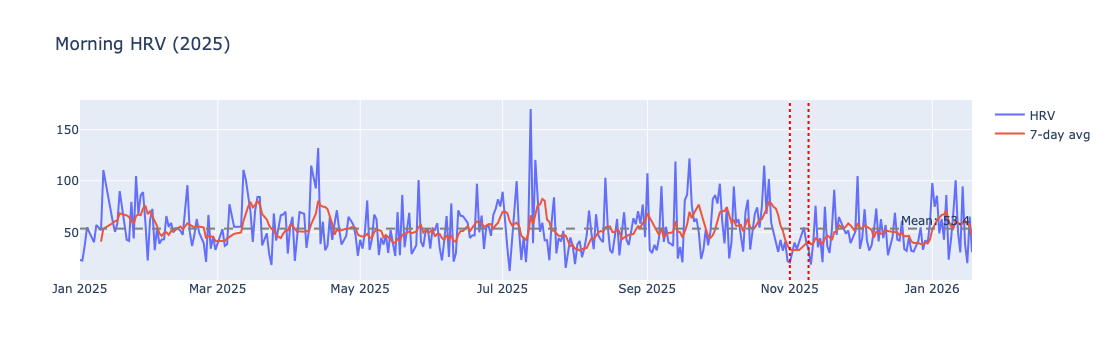

In [23]:
import plotly.graph_objects as go

hrv = pd.read_sql("""
  SELECT date(start_date, '-5 hours') as day, quantity as value
  FROM health_samples 
  WHERE type = 'HKQuantityTypeIdentifierHeartRateVariabilitySDNN'
    AND time(start_date) BETWEEN '04:00' AND '14:00'
    AND start_date >= '2025-01-01'
  ORDER BY start_date
""", conn)

daily = hrv.groupby('day')['value'].first().reset_index()
daily['rolling_7'] = daily['value'].rolling(7).mean()
baseline = daily['value'].mean()

races = ['2025-11-01', '2025-11-09']

fig = go.Figure()
fig.add_trace(go.Scatter(x=daily['day'], y=daily['value'], mode='lines', name='HRV'))
fig.add_trace(go.Scatter(x=daily['day'], y=daily['rolling_7'], mode='lines', name='7-day avg'))
fig.add_hline(y=baseline, line_dash="dash", line_color="gray", annotation_text=f"Mean: {baseline:.1f}")

for race in races:
    fig.add_vline(x=race, line_dash="dot", line_color="red")

fig.update_layout(title='Morning HRV (2025)')
fig.show()

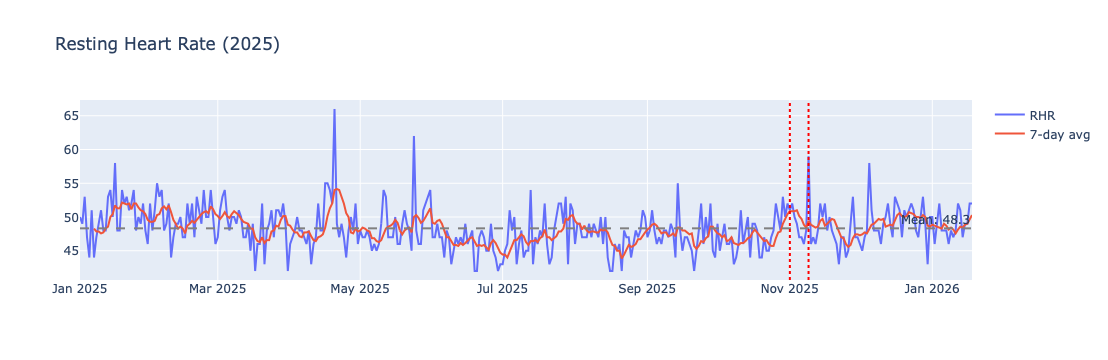

In [22]:
rhr = pd.read_sql("""
  SELECT date(start_date, '-5 hours') as day, quantity as value
  FROM health_samples 
  WHERE type = 'HKQuantityTypeIdentifierRestingHeartRate'
    AND start_date >= '2025-01-01'
  ORDER BY start_date
""", conn)

daily_rhr = rhr.groupby('day')['value'].first().reset_index()
daily_rhr['rolling_7'] = daily_rhr['value'].rolling(7).mean()
baseline_rhr = daily_rhr['value'].mean()

races = ['2025-11-01', '2025-11-09']

fig = go.Figure()
fig.add_trace(go.Scatter(x=daily_rhr['day'], y=daily_rhr['value'], mode='lines', name='RHR'))
fig.add_trace(go.Scatter(x=daily_rhr['day'], y=daily_rhr['rolling_7'], mode='lines', name='7-day avg'))
fig.add_hline(y=baseline_rhr, line_dash="dash", line_color="gray", annotation_text=f"Mean: {baseline_rhr:.1f}")

for race in races:
    fig.add_vline(x=race, line_dash="dot", line_color="red")

fig.update_layout(title='Resting Heart Rate (2025)')
fig.show()

In [25]:
daily_hrv = hrv.groupby('day')['value'].first().reset_index().rename(columns={'value': 'hrv'})
daily_rhr = rhr.groupby('day')['value'].first().reset_index().rename(columns={'value': 'rhr'})

daily_hrv['hrv_7'] = daily_hrv['hrv'].rolling(7).mean()
daily_rhr['rhr_7'] = daily_rhr['rhr'].rolling(7).mean()

merged = daily_hrv.merge(daily_rhr, on='day')
correlation_raw = merged['hrv'].corr(merged['rhr'])
correlation_smoothed = merged['hrv_7'].corr(merged['rhr_7'])

print(f"Daily correlation: {correlation_raw:.3f}")
print(f"7-day avg correlation: {correlation_smoothed:.3f}")

Daily correlation: -0.165
7-day avg correlation: -0.268


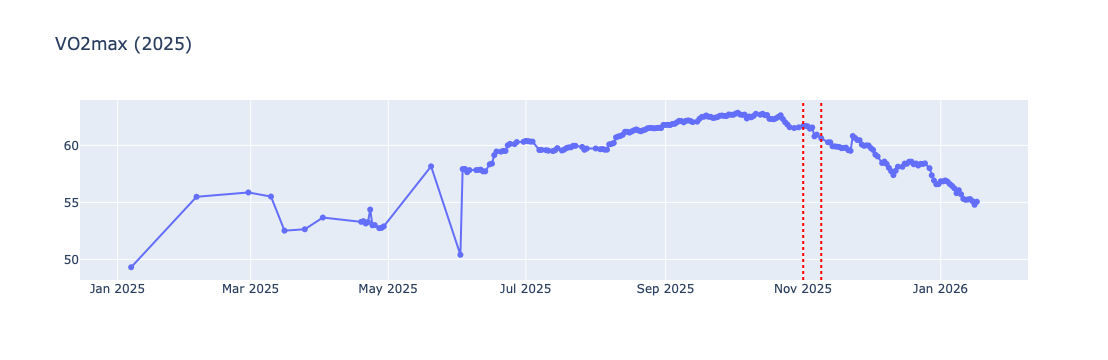

In [26]:
vo2 = pd.read_sql("""
  SELECT date(start_date, '-5 hours') as day, quantity as value
  FROM health_samples 
  WHERE type = 'HKQuantityTypeIdentifierVO2Max'
    AND start_date >= '2025-01-01'
  ORDER BY start_date
""", conn)

daily_vo2 = vo2.groupby('day')['value'].first().reset_index()

races = ['2025-11-01', '2025-11-09']

fig = go.Figure()
fig.add_trace(go.Scatter(x=daily_vo2['day'], y=daily_vo2['value'], mode='lines+markers', name='VO2max'))

for race in races:
    fig.add_vline(x=race, line_dash="dot", line_color="red")

fig.update_layout(title='VO2max (2025)')
fig.show()